In [1]:
import pandas, numpy

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })


In [3]:
input_file = '/Users/adrian/research/bmcbf/004_keilir/results/06_necio_diff_peaks/results_black/DESeq2_results_all_peaks.black.tsv'

In [4]:
df = pandas.read_csv(input_file, sep='\t')
df

,Geneid,Chr,Start,End,Strand,log2FoldChange,padj,countsa,countsb,promoter_genes_s1kb
0,peak_38914,chr8,144495709,144499509,.,1.874213,1.736010e-65,4026,618,LOC101928953;PPP1R16A
1,peak_39571,chr9,93669117,93670991,.,2.111430,3.718923e-55,1254,170,NaN
2,peak_21382,chr2,26556617,26559861,.,1.644076,1.277938e-52,2776,516,OTOF
3,peak_27350,chr22,30379213,30382143,.,1.725254,1.277938e-52,2356,408,KIAA1656;RNF215
4,peak_35264,chr7,1465331,1469875,.,1.643510,1.613999e-52,2874,522,NaN
...,...,...,...,...,...,...,...,...,...,...
38446,peak_36276,chr7,75018637,75019188,.,-0.000154,9.994138e-01,398,208,NaN
38447,peak_20369,chr19,46812865,46813496,.,0.000104,9.994352e-01,678,374,NaN
38448,peak_31485,chr4,8329417,8331838,.,0.000030,9.998030e-01,1546,944,NaN
38449,peak_7558,chr11,66221755,66223020,.,-0.000006,9.999665e-01,1238,656,NaN


In [5]:
sum((df['padj'] < 0.05))

23624

In [6]:
# get all genes that pass significance
sig = df[(df['padj'] < 0.05) & (df['promoter_genes_s1kb'].notna()) & (numpy.abs(df['log2FoldChange']) >= 1)]
sig

,Geneid,Chr,Start,End,Strand,log2FoldChange,padj,countsa,countsb,promoter_genes_s1kb
0,peak_38914,chr8,144495709,144499509,.,1.874213,1.736010e-65,4026,618,LOC101928953;PPP1R16A
2,peak_21382,chr2,26556617,26559861,.,1.644076,1.277938e-52,2776,516,OTOF
3,peak_27350,chr22,30379213,30382143,.,1.725254,1.277938e-52,2356,408,KIAA1656;RNF215
7,peak_18210,chr17,81453882,81455765,.,2.697078,3.310864e-49,1252,124,BAHCC1
13,peak_24143,chr2,240932810,240935925,.,1.823995,7.032938e-47,1890,306,CROCC2
...,...,...,...,...,...,...,...,...,...,...
14042,peak_37399,chr8,58596026,58596348,.,-1.098685,2.034758e-04,146,274,NSMAF
14211,peak_10594,chr13,110964358,110964717,.,-1.025540,2.350693e-04,92,148,LINC00431
17884,peak_36777,chr8,6648851,6649706,.,-1.140004,3.178655e-03,696,1190,MCPH1-AS1
18457,peak_37468,chr8,74823255,74823585,.,-1.086698,4.445866e-03,82,168,PI15


In [7]:
genes = sorted(set(sig["promoter_genes_s1kb"].dropna().str.split(";").explode().str.strip()))
print(len(genes), genes[:10])
'MLANA' in genes


686 ['AATK', 'ABCA4', 'ABCC3', 'ABCD4', 'ABHD14B', 'ABHD17C', 'ABLIM3', 'ACE', 'ACSF2', 'ACSM3']


True

In [8]:
# for each gene, get median log2fc and median p. store in df
x = []; y = []; names = []
for gene in genes:

    #print(gene)

    sub_df = sig[sig["promoter_genes_s1kb"].str.split(";").apply(lambda xs: gene in [x.strip() for x in xs])]


    #print(sub_df)

    fc = numpy.median(sub_df['log2FoldChange'])
    p = numpy.median(-numpy.log10(sub_df['padj']))
    #print(fc, p)
    x.append(fc)
    y.append(p)
    names.append(gene)
    


    

In [9]:
results = pandas.DataFrame({
    "median FE": x,
    "median P": y,
    "gene": names
})
results

,median FE,median P,gene
0,1.489045,30.719027,AATK
1,1.062080,6.307242,ABCA4
2,2.092975,38.175787,ABCC3
3,1.170846,12.084329,ABCD4
4,1.550516,18.633425,ABHD14B
...,...,...,...
681,1.067012,9.317444,ZFTRAF1
682,1.406041,24.256693,ZMYND10
683,1.147483,26.643562,ZNF205-AS1
684,-1.228756,8.126408,ZNF442


In [10]:
pos_df = results.loc[results["median FE"].gt(0)].sort_values("median P", ascending=False)
neg_df = results.loc[results["median FE"].lt(0)].sort_values("median P", ascending=False)

pos_df.to_csv("positive_FE_sorted_by_P.csv", index=False)
neg_df.to_csv("negative_FE_sorted_by_P.csv", index=False)


pos_df.head(25)

,median FE,median P,gene
510,1.874213,64.760448,PPP1R16A
303,1.874213,64.760448,LOC101928953
240,1.725254,51.893490,KIAA1656
547,1.725254,51.893490,RNF215
526,1.318308,43.611403,PTPN23
657,1.163890,42.213051,TSPOAP1
135,1.271687,41.000532,DGCR8
565,1.530804,39.606121,SFI1
308,1.671393,39.279135,LOC105369395
2,2.092975,38.175787,ABCC3


In [11]:
neg_df.head(25)

,median FE,median P,gene
329,-1.345251,27.649530,LOC105375322
373,-1.018305,24.320870,LOC124904235
269,-1.314832,22.214748,LINC01265
183,-1.753400,21.606872,FSD2
43,-1.602553,21.389869,ATG16L1
554,-1.602553,21.389869,SCARNA5
596,-1.514550,20.825539,SMCO2
627,-1.301259,19.480062,TGIF1
618,-1.263518,16.544955,TACC2
279,-1.335001,16.544955,LINC02086


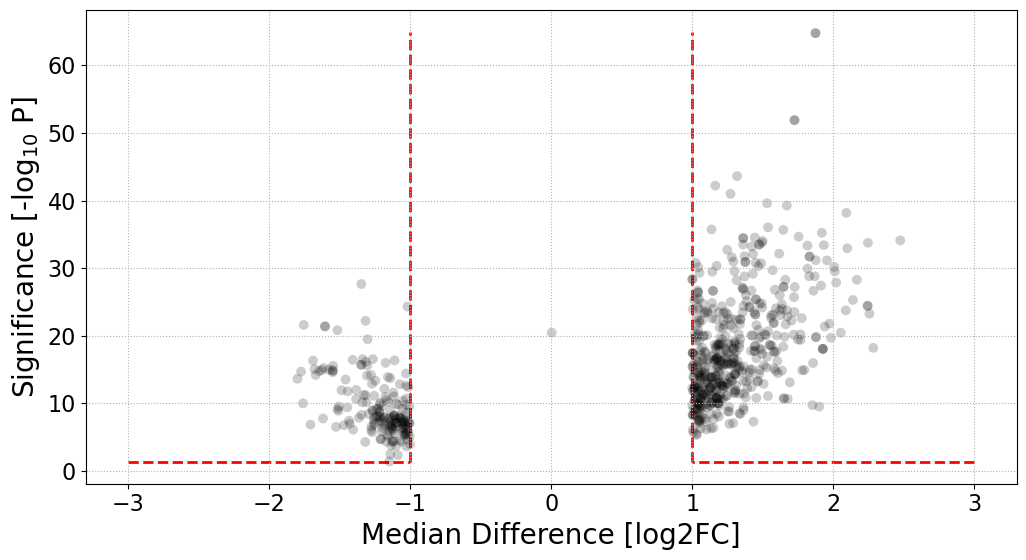

In [14]:
# plot volcano
matplotlib.pyplot.scatter(x, y, s=50, c='black', marker='o', alpha=1/5, edgecolors='none')

matplotlib.pyplot.plot([-3, -1], [-numpy.log10(0.05), -numpy.log10(0.05)], lw=2, ls='--', color='red', zorder=0)
matplotlib.pyplot.plot([3, 1], [-numpy.log10(0.05), -numpy.log10(0.05)], lw=2, ls='--', color='red', zorder=0)
matplotlib.pyplot.plot([-1, -1], [-numpy.log10(0.05), 65], lw=2, ls='--', color='red', zorder=0)
matplotlib.pyplot.plot([1, 1], [-numpy.log10(0.05), 65], lw=2, ls='--', color='red', zorder=0)

matplotlib.pyplot.xlabel('Median Difference [log2FC]')
matplotlib.pyplot.ylabel('Significance [-log$_{10}$ P]')
matplotlib.pyplot.grid(ls=':', zorder=0)
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()